In [ ]:
from google.colab import drive
import zipfile
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/Plant_Disease_Classification_224.zip'

In [ ]:
extract_path = '/content/Plant_Disease_Classification_224'

In [ ]:
import os
os.makedirs(extract_path, exist_ok=True)

In [ ]:
import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")
print("Files are available at:", extract_path)

Dataset unzipped successfully!
Files are available at: /content/Plant_Disease_Classification_224


In [ ]:
os.listdir(extract_path)

['test.csv',
 'train',
 'train.csv',
 'valid',
 'label.num_disease.json',
 'test',
 'valid.csv']

In [ ]:
import os
import json
import pandas as pd

In [ ]:
DATASET_PATH = "/content/Plant_Disease_Classification_224"

In [ ]:
train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")
test_dir  = os.path.join(DATASET_PATH, "test")

In [ ]:
train_csv_path = os.path.join(DATASET_PATH, "train.csv")
valid_csv_path = os.path.join(DATASET_PATH, "valid.csv")
test_csv_path  = os.path.join(DATASET_PATH, "test.csv")

In [ ]:
label_json_path = os.path.join(DATASET_PATH, "label_num_disease.json")

In [ ]:
train_df = pd.read_csv(train_csv_path)
valid_df = pd.read_csv(valid_csv_path)
test_df = pd.read_csv(test_csv_path)

In [ ]:
label_json_path = os.path.join(DATASET_PATH, "label.num_disease.json")

with open(label_json_path, "r") as f:
    label_map = json.load(f)

print("Dataset loaded successfully!")
print("Train images folder:", train_dir)
print("Valid images folder:", valid_dir)
print("Test images folder:", test_dir)

print("\nTrain CSV shape:", train_df.shape)
print("Valid CSV shape:", valid_df.shape)
print("Test CSV shape:", test_df.shape)

print("\nTrain CSV columns:")
print(train_df.columns)

print("\nLabel mapping:")
print(label_map)

Dataset loaded successfully!
Train images folder: /content/Plant_Disease_Classification_224/train
Valid images folder: /content/Plant_Disease_Classification_224/valid
Test images folder: /content/Plant_Disease_Classification_224/test

Train CSV shape: (5000, 3)
Valid CSV shape: (1448, 3)
Test CSV shape: (1930, 3)

Train CSV columns:
Index(['image_path', 'label', 'disease_name'], dtype='object')

Label mapping:
{'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}


In [ ]:
train_df.head()

,image_path,label,disease_name
0,train/Cassava___bacterial_blight/2932123995_jp...,0,Cassava___bacterial_blight
1,train/Cassava___bacterial_blight/1410898675_jp...,0,Cassava___bacterial_blight
2,train/Cassava___bacterial_blight/416062259_jpg...,0,Cassava___bacterial_blight
3,train/Cassava___bacterial_blight/2998282647_jp...,0,Cassava___bacterial_blight
4,train/Cassava___bacterial_blight/3504991692_jp...,0,Cassava___bacterial_blight


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    fill_mode="nearest"
)

valid_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

valid_generator = valid_test_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5000 images belonging to 5 classes.
Found 1448 images belonging to 5 classes.
Found 1930 images belonging to 5 classes.


In [ ]:
print("Number of classes:", train_generator.num_classes)
print("Class names:", train_generator.class_indices)

Number of classes: 5
Class names: {'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}


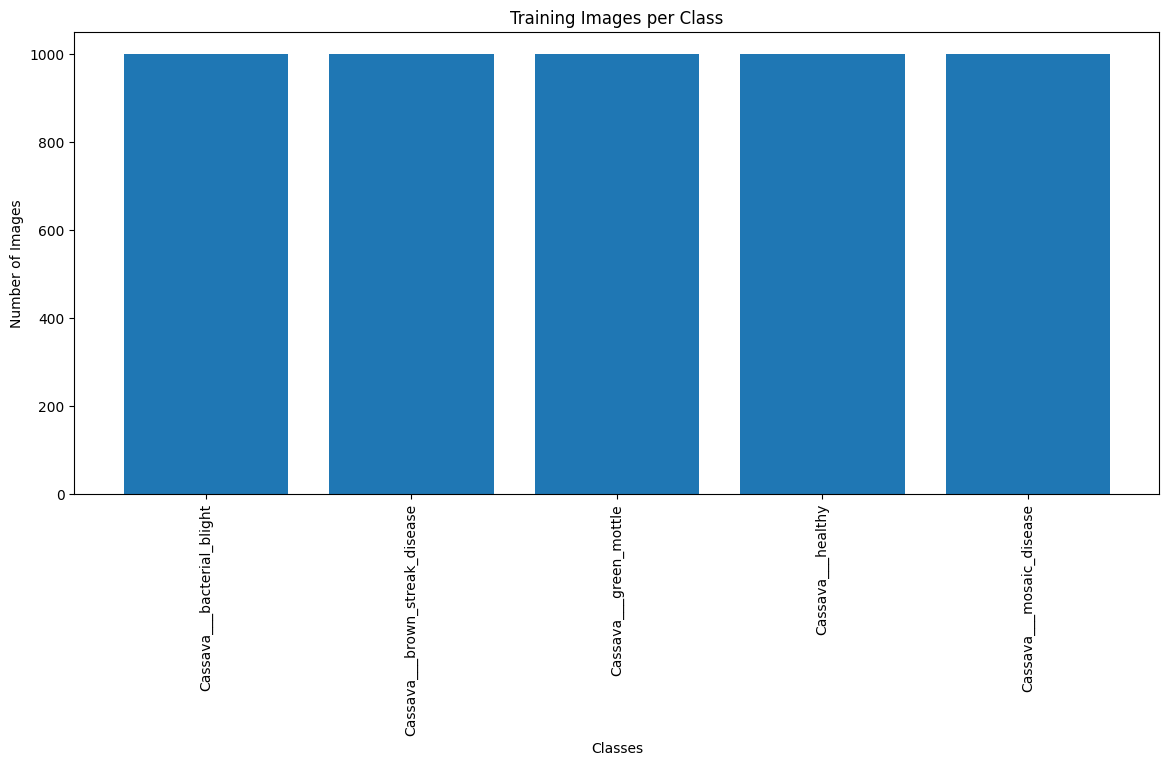

In [ ]:
import matplotlib.pyplot as plt
import os

class_names = list(train_generator.class_indices.keys())
class_counts = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    count = len(os.listdir(class_path))
    class_counts.append(count)

plt.figure(figsize=(14, 6))
plt.bar(class_names, class_counts)
plt.xticks(rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Training Images per Class")
plt.show()

In [ ]:
for name, count in zip(class_names, class_counts):
    print(name, ":", count)

Cassava___bacterial_blight : 1000
Cassava___brown_streak_disease : 1000
Cassava___green_mottle : 1000
Cassava___healthy : 1000
Cassava___mosaic_disease : 1000


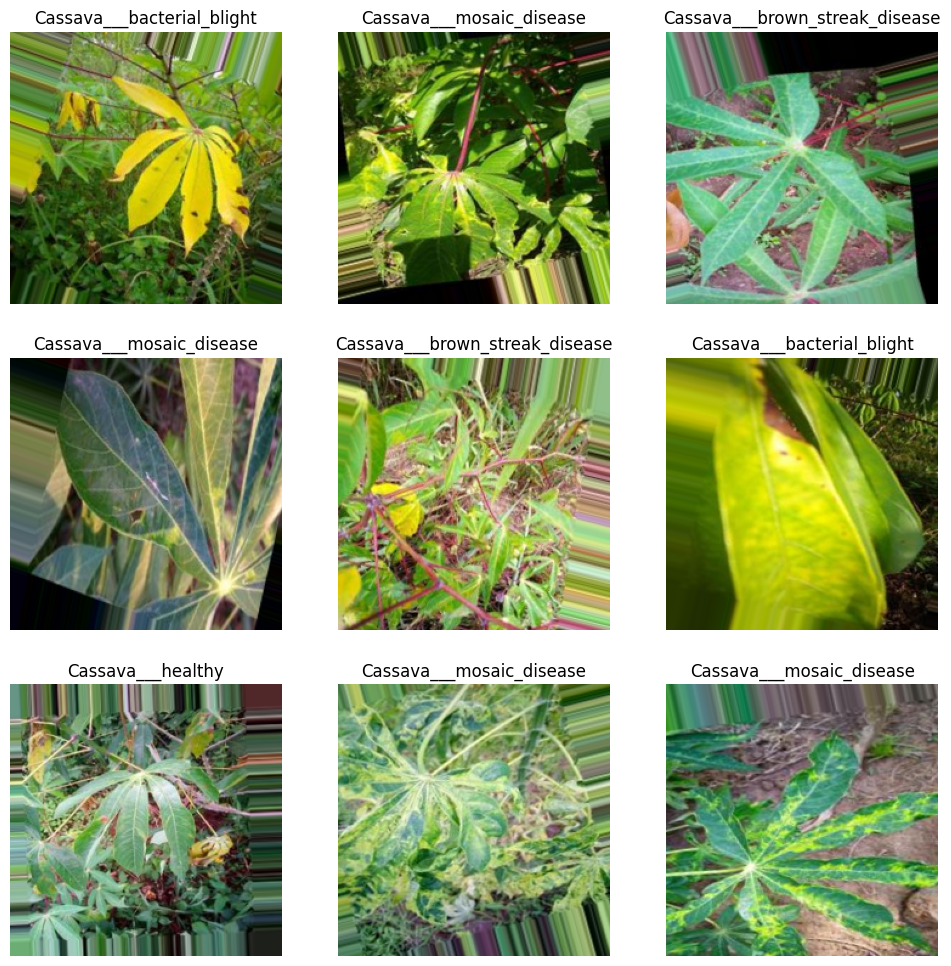

In [ ]:
import numpy as np

images, labels = next(train_generator)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    class_index = np.argmax(labels[i])
    class_name = class_names[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense

In [ ]:
IMG_SIZE = 224
NUM_CLASSES = train_generator.num_classes

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,269,189 (50.62 MB)

 Trainable params: 13,268,229 (50.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 93s 502ms/step - accuracy: 0.2004 - loss: 4.3940 - val_accuracy: 0.1948 - val_loss: 1.6778
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 444ms/step - accuracy: 0.1992 - loss: 1.6414 - val_accuracy: 0.2210 - val_loss: 1.6544
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 443ms/step - accuracy: 0.1956 - loss: 1.6316 - val_accuracy: 0.2113 - val_loss: 1.6207
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 439ms/step - accuracy: 0.1970 - loss: 1.6165 - val_accuracy: 0.2300 - val_loss: 1.6077
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 445ms/step - accuracy: 0.1886 - loss: 1.6137 - val_accuracy: 0.2244 - val_loss: 1.6087
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 449ms/step - accuracy: 0.1968 - loss: 1.6115 - val_accuracy: 0.2196 - val_loss: 1.6116
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 452ms/step - accuracy: 0.1946 - loss: 1.6290 - val_accuracy: 0.2169 - val_loss: 1.6084
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 451ms/step - accuracy: 0.1910 - loss: 1

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.2171 - loss: 1.6152
Test Loss: 1.6151565313339233
Test Accuracy: 0.2170984447002411


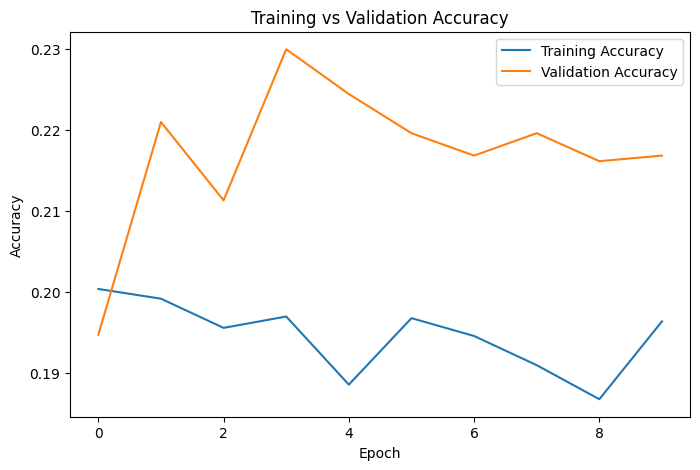

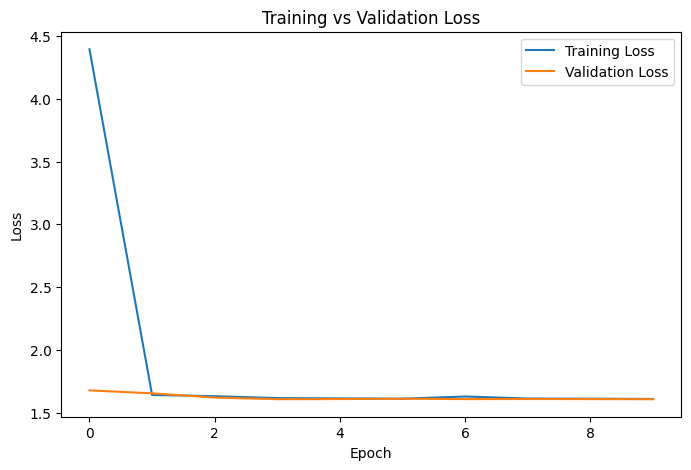

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()